In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1

In [2]:
# Q1
import pandas as pd

problem1 = pd.read_csv("problem1.csv")
problem1.head()


,x
0,-0.003032
1,0.007720
2,-0.020493
3,0.000892
4,-0.010028


In [3]:
def first4Moments(sample):
    mu_hat = sample.mean()
    sigma2_hat = sample.var()
    skew_hat = sample.skew()
    kurt_hat = sample.kurt()

    return mu_hat, sigma2_hat, skew_hat, kurt_hat


sample = problem1["x"]

m, s2, sk, k = first4Moments(sample)

print(f"Mean {m}")
print(f"Variance {s2}")
print(f"Skew {sk}")
print(f"Kurtosis {k}")


Mean 0.0011043942883968638
Variance 9.624822112193506e-05
Skew -0.6698366405653347
Kurtosis 2.3576142339723893


### 1.a

Sample moments: mean ≈ 0.0011, variance ≈ 9.62e-05, **skewness ≈ -0.670**, **excess kurtosis ≈ 2.358**.

- **Normal** — ruled out by **skewness**. A normal distribution is symmetric with skew ~= 0, but the sample skew is -0.67, clearly nonzero. It's also ruled out by kurtosis, since normal requires excess kurtosis = 0, and the sample shows heavy tails at 2.36.

- **Student's t** — ruled out by **skewness**. The student's t-distribution is symmetric around its mean with skew ~= 0, so it cannot produce the observed skew of -0.67. 

- **Lognormal** — ruled out by **skewness**. A lognormal variable is always positively skewed and it cannot be negatively skewed. The sample's skew is -0.67 and negatively skewed, which a lognormal distribution can never produce.

- **Normal Inverse Gaussian (NIG)** — **plausible**. NIG is a flexible 4-parameter family that can have both nonzero skewness and excess kurtosis. The sample satisfies nonzero skewness and positive excess kurtosis. So NIG can plausibly match both the observed skewness and kurtosis simultaneously.


In [4]:
from scipy.stats import norm

# fit Normal by matching mean and variance (method of moments)
mu_norm = sample.mean()
sigma_norm = sample.std()

norm_fit = norm(loc=mu_norm, scale=sigma_norm)

print(f"Fitted Normal: mu = {mu_norm}, sigma = {sigma_norm}")


Fitted Normal: mu = 0.0011043942883968638, sigma = 0.009810617774734427


In [5]:
q01 = norm_fit.ppf(0.01)

n_below = (sample < q01).sum()
n_expected = 0.01 * len(sample)

print(f"Normal 1% quantile = {q01}")
print(f"Observations below quantile = {n_below}")
print(f"Expected observations = {n_expected}")


Normal 1% quantile = -0.021718515514883855
Observations below quantile = 26
Expected observations = 10.0


### 1.b

There are 26 observations fall below the fitted Normal's 1% quantile (-0.02172), versus 10 expected (1% of 1000 observations).

Since it is 2.6 times more than expected and consistent with the negative skew and excess kurtosis found earlier: the left tail of the actual sample is fatter than a Normal distribution predicts.

### 1.c

The Normal fit matches the sample's mean and variance by construction, so it gets the center and overall spread right. The error shows up in the **tails**, and specifically the **left tail**:

- **Left tail** — The Normal predicts only 10 observations below its 1% quantile, but 26 actually occur. Real losses are more frequent and more extreme than the Normal implies, so a Normal-based VaR/ES would understate downside risk.
- **Right tail** — since the sample is negatively skewed, its right tail is thinner than its left; the symmetric Normal would tend to overstate the chance of correspondingly large gains relative to what's actually observed.


## Question 2

In [6]:
# Q2

problem2 = pd.read_csv("problem2.csv")
problem2.head()

,x,y
0,0.552447,3.351035
1,-1.245128,-1.966928
2,0.905569,5.632345
3,0.681733,4.292113
4,-0.159037,0.538857


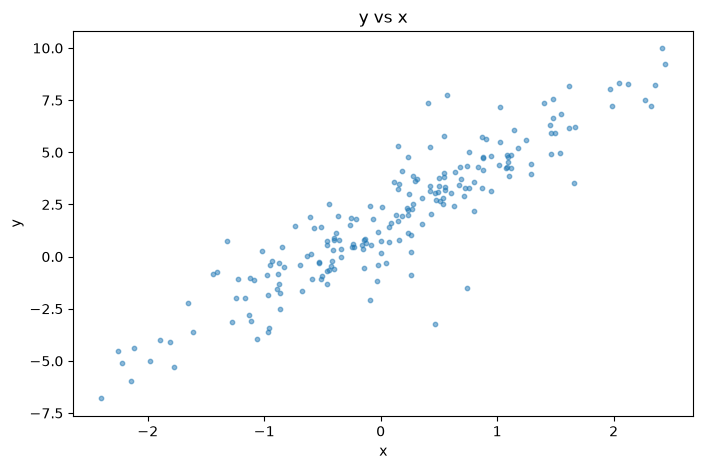

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(problem2["x"], problem2["y"], alpha=0.5, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("y vs x")
plt.show()


### 2.a

The scatter shows a clear and strong linear relationship between `x` and `y`. The scatter is roughly symmetric around the fitted line with fairly constant spread across the range of `x`, so the error term is very likly to follow a **Normal distribution**.


### 2.b

The data may violates **Assumption 5&7: the error term is normally distributed and have consistant variance**. A Normal error should scatter symmetrically around the trend. But from the graph we can tell the stray points lean to one side, especially in the middle part.


### Fit three models

**1. OLS (with standard errors)**

In [8]:
import statsmodels.api as sm

X = sm.add_constant(problem2["x"])
y = problem2["y"]

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     957.8
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           8.70e-78
Time:                        05:41:35   Log-Likelihood:                -343.01
No. Observations:                 200   AIC:                             690.0
Df Residuals:                     198   BIC:                             696.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5607      0.096     16.212      0.0

**2. Maximum likelihood under a Normal error**

In [9]:
from scipy.optimize import minimize
from scipy.stats import norm as norm_dist

x = problem2["x"].values
y = problem2["y"].values
n = len(y)

def neg_ll_normal(params):
    b0, b1, sigma = params
    resid = y - (b0 + b1 * x)
    return -np.sum(norm_dist.logpdf(resid, loc=0, scale=sigma))

start = [0.0, 0.0, y.std()]
res_normal = minimize(neg_ll_normal, start, method="Nelder-Mead")
b0_mle_n, b1_mle_n, sigma_mle_n = res_normal.x

print(f"MLE (Normal): intercept = {b0_mle_n}, slope = {b1_mle_n}, sigma = {sigma_mle_n}")


MLE (Normal): intercept = 1.5607720994494985, slope = 2.9907939799194194, sigma = 1.3445947768089943


**3. Maximum likelihood under a Student's t error**

In [10]:
from scipy.stats import t as t_dist

def neg_ll_t(params):
    b0, b1, log_scale, log_nu = params
    scale = np.exp(log_scale)
    nu = np.exp(log_nu)
    resid = y - (b0 + b1 * x)
    return -np.sum(t_dist.logpdf(resid, df=nu, loc=0, scale=scale))

start_t = [0.0, 0.0, np.log(y.std()), np.log(5.0)]
res_t = minimize(neg_ll_t, start_t, method="Nelder-Mead")
b0_mle_t, b1_mle_t, log_scale_t, log_nu_t = res_t.x
scale_mle_t, nu_mle_t = np.exp(log_scale_t), np.exp(log_nu_t)

print(f"MLE (t): intercept = {b0_mle_t}, slope = {b1_mle_t}, scale = {scale_mle_t}, nu = {nu_mle_t}")


MLE (t): intercept = 1.547963920163439, slope = 3.0191633109643043, scale = 0.9354845290381152, nu = 3.6320650180150102


In [11]:
def aicc(loglik, k, n):
    aic = 2 * k - 2 * loglik
    return aic + (2 * k * (k + 1)) / (n - k - 1)

n = len(y)

# OLS / MLE-Normal: params = (alpha, beta, sigma) -> k = 3
ll_ols = ols_model.llf
k_ols = 3
aicc_ols = aicc(ll_ols, k_ols, n)

ll_normal = -res_normal.fun
k_normal = 3
aicc_normal = aicc(ll_normal, k_normal, n)

# MLE-t: params = (alpha, beta, scale, nu) -> k = 4
ll_t = -res_t.fun
k_t = 4
aicc_t = aicc(ll_t, k_t, n)

print("Model            alpha      beta      error params            AICc")
print(f"OLS              {ols_model.params['const']:.4f}    {ols_model.params['x']:.4f}    sigma={ols_model.mse_resid**0.5:.4f}          {aicc_ols:.2f}")
print(f"MLE Normal       {b0_mle_n:.4f}    {b1_mle_n:.4f}    sigma={sigma_mle_n:.4f}          {aicc_normal:.2f}")
print(f"MLE t            {b0_mle_t:.4f}    {b1_mle_t:.4f}    scale={scale_mle_t:.4f}, nu={nu_mle_t:.2f}  {aicc_t:.2f}")


Model            alpha      beta      error params            AICc
OLS              1.5607    2.9908    sigma=1.3514          692.14
MLE Normal       1.5608    2.9908    sigma=1.3446          692.14
MLE t            1.5480    3.0192    scale=0.9355, nu=3.63  665.33


### Results and model choice

| Model | α (intercept) | β (slope) | error params | AICc |
|---|---|---|---|---|
| OLS | 1.5607 | 2.9908 | σ = 1.3514 | 692.14 |
| MLE, Normal error | 1.5608 | 2.9908 | σ = 1.3446 | 692.14 |
| MLE, Student's t error | 1.5480 | 3.0192 | scale = 0.9355, ν ≈ 3.63 | **665.33** |

α and β are nearly identical across all three fits, the point estimate of the trend line is not very sensitive to the error-distribution assumption. But **AICc strongly favors the Student's t model** 

### 2.c

β: OLS = 2.9908, MLE-Normal = 2.9908, MLE-t = 3.0192. OLS and the Normal MLE land essentially on top of each other, and the t-fit is only slightly higher (~1% difference).

Yes, the β doesn't depend on either assumption 5 (homoskedasticity) or assumption 7 (normality). It only needs the errors to average to zero and be uncorrelated with the regressor. So violating those two, as this data does, is not expected to shift the slope estimate meaningfully, and it didn't.


In [12]:
from scipy.stats import skew, kurtosis

resid_ols = y - (ols_model.params["const"] + ols_model.params["x"] * x)

print(f"Residual skew = {skew(resid_ols, bias=False):.3f}")
print(f"Residual excess kurtosis = {kurtosis(resid_ols, bias=False):.3f}")

# look at the largest-magnitude residuals: how much log-density do Normal vs t assign them?
worst_idx = np.argsort(-np.abs(resid_ols))[:5]
for i in worst_idx:
    r = resid_ols[i]
    ll_n = norm_dist.logpdf(r, loc=0, scale=sigma_mle_n)
    ll_t = t_dist.logpdf(r, df=nu_mle_t, loc=0, scale=scale_mle_t)
    print(f"resid={r:7.3f}   Normal logpdf={ll_n:7.3f}   t logpdf={ll_t:7.3f}   diff={ll_t - ll_n:6.3f}")


Residual skew = -0.362
Residual excess kurtosis = 3.617
resid= -6.167   Normal logpdf=-11.732   t logpdf= -6.854   diff= 4.878
resid= -5.287   Normal logpdf= -8.946   t logpdf= -6.205   diff= 2.741
resid=  4.586   Normal logpdf= -7.031   t logpdf= -5.623   diff= 1.409
resid=  4.489   Normal logpdf= -6.788   t logpdf= -5.537   diff= 1.251
resid= -3.371   Normal logpdf= -4.358   t logpdf= -4.442   diff=-0.084


### 2.d

The **shape of the error distribution**, specifically the **tails**.

The OLS residuals have skew ≈ -0.36 and excess kurtosis ≈ 3.6: a handful of large, mostly one-sided outliers (e.g. residuals of -6.17, -5.29, +4.59, +4.49). The Normal's log-density decays like -r², so it charges huge log-likelihood penalties for these, while the t-distribution's power-law tails charge far less.


In [13]:
from scipy.stats import t as t_dist2

for q in [0.95, 0.995]:
    qn = norm_dist.ppf(q, loc=0, scale=sigma_mle_n)
    qt = t_dist2.ppf(q, df=nu_mle_t, loc=0, scale=scale_mle_t)
    print(f"{q*100:>5}% quantile:  Normal = {qn:.4f}   t = {qt:.4f}   ({'t wider' if qt > qn else 'Normal wider'})")


 95.0% quantile:  Normal = 2.2117   t = 2.0538   (Normal wider)
 99.5% quantile:  Normal = 3.4634   t = 4.6201   (t wider)


### 2.e — Normal vs. t quantiles, and choosing a capital buffer

| Quantile | Normal | Student's t | Wider |
|---|---|---|---|
| 95% | 2.2117 | 2.0538 | **Normal** |
| 99.5% | 3.4634 | 4.6201 | **t** |

**Why they cross.** The two densities are both centered at 0 and have total  probability sum to 1, but very different shapes: the t-distribution (ν ≈ 3.6) has a taller peak and fatter tails than the Normal. The one have heavier peak will have thinner tails and same story for the opposite. So, at a moderate quantile like 95%, the t distribution's cutoff is actually a bit *smaller* than the Normal's, but at a deep-tail quantile like 99.5%, the t's fat tail overtakes the Normal and its cutoff becomes much larger.

**I wiil choose the t-based 99.5% quantile for capital buffer** Because the Normal model underestimates exactly this region because its tails decay too fast. A capital buffer exists specifically to absorb rare, severe losses. the whole point is protection against the tail, not the typical day. Sizing a buffer off the Normal's 99.5% quantile 3.46 would understate how bad a severe loss can be. The t-based quantile 4.62 is wider here for the right reason to reflect the actual observed in the data.


## Question 3

In [14]:
# Q3
problem3 = pd.read_csv("problem3.csv")
problem3.head()


,x1,x2,x3,x4
0,-1.383645,-2.686309,-1.371254,0.396672
1,0.095933,0.013816,-0.723778,-1.028177
2,1.325026,2.367298,-0.009454,2.799896
3,-1.718078,-5.102044,-2.278599,0.544008
4,0.502742,0.093502,-0.151283,1.095976


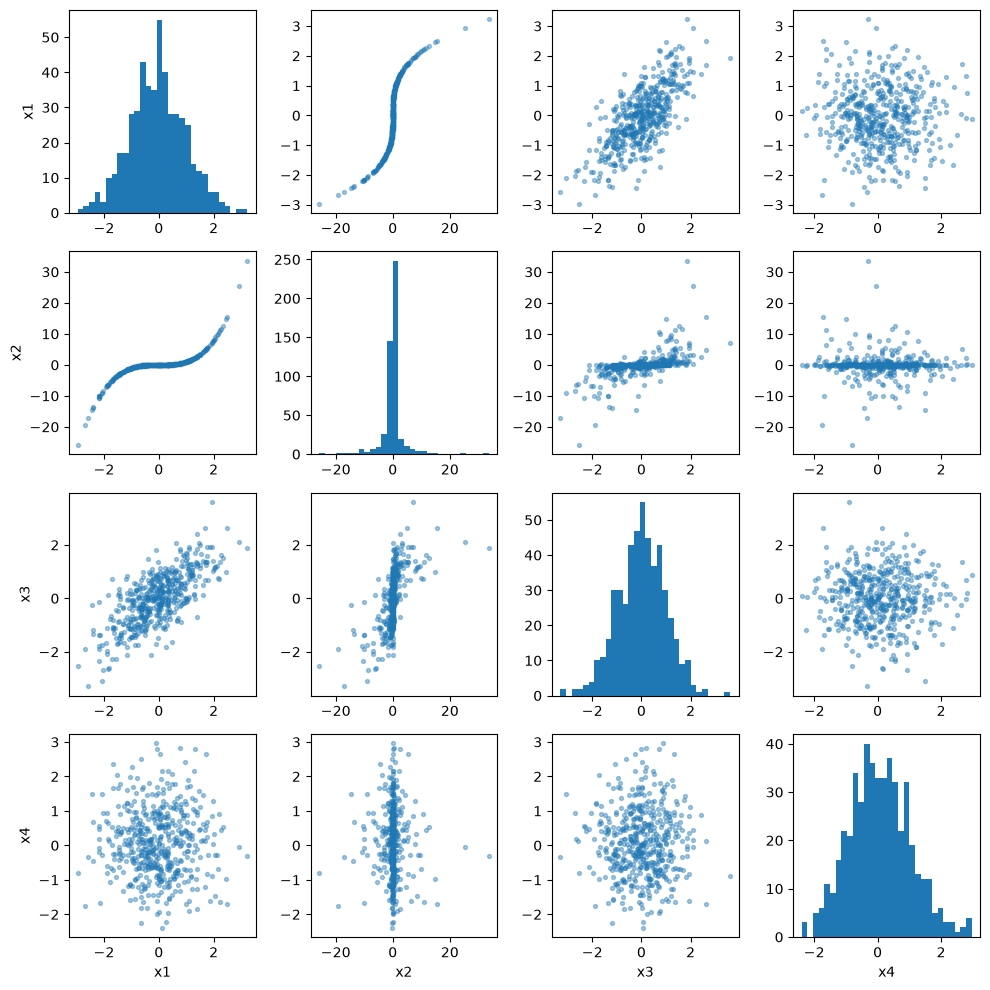

In [15]:
cols = problem3.columns
fig, axes = plt.subplots(len(cols), len(cols), figsize=(10, 10))

for i, ci in enumerate(cols):
    for j, cj in enumerate(cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(problem3[ci], bins=30)
        else:
            ax.scatter(problem3[cj], problem3[ci], alpha=0.4, s=8)
        if i == len(cols) - 1:
            ax.set_xlabel(cj)
        if j == 0:
            ax.set_ylabel(ci)

plt.tight_layout()
plt.show()


### 3.a

**x1 and x2**, since the scatter shows a curved, non-linear relationship. Pearson penalizes the curvature since it only sees linear association, while Spearman (rank-based) is nearly unaffected by monotonic curvature.

In [16]:
print("Pearson:")
print(problem3.corr(method="pearson").round(3))
print("\nSpearman:")
print(problem3.corr(method="spearman").round(3))


Pearson:
       x1     x2     x3     x4
x1  1.000  0.799  0.719 -0.005
x2  0.799  1.000  0.588 -0.021
x3  0.719  0.588  1.000 -0.009
x4 -0.005 -0.021 -0.009  1.000

Spearman:
       x1     x2     x3     x4
x1  1.000  0.972  0.684  0.000
x2  0.972  1.000  0.667 -0.001
x3  0.684  0.667  1.000 -0.002
x4  0.000 -0.001 -0.002  1.000


In [17]:
import itertools

pearson_corr = problem3.corr(method="pearson")
spearman_corr = problem3.corr(method="spearman")

gaps = []
for a, b in itertools.combinations(problem3.columns, 2):
    p = pearson_corr.loc[a, b]
    s = spearman_corr.loc[a, b]
    gaps.append((a, b, p, s, abs(s - p)))

gaps_df = pd.DataFrame(gaps, columns=["var1", "var2", "pearson", "spearman", "abs_gap"])
gaps_df = gaps_df.sort_values("abs_gap", ascending=False).reset_index(drop=True)
gaps_df


,var1,var2,pearson,spearman,abs_gap
0,x1,x2,0.799092,0.971930,0.172838
1,x2,x3,0.587614,0.667422,0.079808
2,x1,x3,0.719467,0.683910,0.035557
3,x2,x4,-0.020923,-0.001131,0.019792
4,x3,x4,-0.008605,-0.002422,0.006183
5,x1,x4,-0.004680,0.000189,0.004869


### 3.b

Largest gap: **(x1, x2)** — Pearson ≈ 0.799, Spearman ≈ 0.972, |gap| ≈ 0.173. This is far larger than the next-biggest gap, (x2, x3) at ≈ 0.080.


### 3.c — Mechanism behind the gap

`x2` is essentially `x1³` plus noise — a perfect monotonic but nonlinear (S-shaped) relationship: flat near the middle, steep at the extremes.

**Mechanism**: Pearson fits a straight line to the raw values, so the flat middle and cubed-out extremes drag it below 1 (≈0.80) even though the relationship is fully deterministic. Spearman works on ranks instead — since `x1³` is strictly increasing, ranking preserves the order almost exactly, so it stays near 1 (≈0.97).

**Which is honest**: Spearman — `x1` and `x2` are (almost) perfectly related, just not linearly. Pearson isn't wrong, it's answering a narrower question ("is the relationship linear?"), and for this pair that's the less informative one.


## Question 4

In [18]:
# Q4
problem4 = pd.read_csv("problem4.csv")
problem4.head()


,x1,x2
0,-0.551088,-0.896356
1,0.892005,1.640851
2,0.218606,-0.842202
3,-1.068407,1.759723
4,-0.551480,0.050912


In [19]:
cov_matrix = problem4.cov()
cov_matrix


,x1,x2
x1,1.099875,1.696902
x2,1.696902,4.104749


In [20]:
sigma11 = cov_matrix.loc["x1", "x1"]
sigma22 = cov_matrix.loc["x2", "x2"]
sigma12 = cov_matrix.loc["x1", "x2"]

cond_var_x2_given_x1 = sigma22 - sigma12**2 / sigma11
reduction_factor = sigma22 / cond_var_x2_given_x1

print(f"Var(x2) = {sigma22}")
print(f"Var(x2 | x1) = {cond_var_x2_given_x1}")
print(f"Variance reduction factor = {reduction_factor}")


Var(x2) = 4.104748962420847
Var(x2 | x1) = 1.486745678295288
Variance reduction factor = 2.7608951701325126


### 4.a

Let `x1` be the first block (`x1` = block 1, size 1×1) and `x2` be the second block (`x2` = block 2, size 1×1), so

$$\Sigma = \begin{bmatrix}\Sigma_{11} & \Sigma_{12}\\ \Sigma_{21} & \Sigma_{22}\end{bmatrix} = \begin{bmatrix}1.0999 & 1.6969\\ 1.6969 & 4.1047\end{bmatrix}$$

The conditional variance of `x2` given `x1` is

$$\text{Var}(x_2 \mid x_1) = \Sigma_{22} - \Sigma_{21}\Sigma_{11}^{-1}\Sigma_{12}$$

which for scalar blocks is just $\Sigma_{22} - \Sigma_{12}^2/\Sigma_{11}$. Plugging in: $4.1047 - 1.6969^2/1.0999 \approx 1.4867$.

**By what factor does uncertainty fall?** Comparing the conditional variance to the unconditional variance $\Sigma_{22}$:

$$\frac{\text{Var}(x_2)}{\text{Var}(x_2\mid x_1)} = \frac{\Sigma_{22}}{\Sigma_{22} - \Sigma_{21}\Sigma_{11}^{-1}\Sigma_{12}}$$

Plugging in get **variance** of `x2` shrinks by a factor of about **2.76** once `x1` is known.


### 4.b

**No** — under the multivariate Normal, Var(x2 | x1) does not depend on the observed value of x1.

$$\text{Var}(x_2 \mid x_1) = \Sigma_{22} - \Sigma_{21}\Sigma_{11}^{-1}\Sigma_{12}$$

Every term on the right is an entry of Σ; there is no `x1` in the formula at all, so it's a fixed number regardless of what value x1 turns out to take. This is in contrast to the conditional *mean*, $\mu_2 + \Sigma_{21}\Sigma_{11}^{-1}(x_1-\mu_1)$, which does depend on x1 through that last term. Conditioning on x1 shifts where x2 is centered, but not how spread out it is around that center — the conditional variance is homoskedastic in x1.


### 4.c

The conditional mean of `x2` given `x1` is

$$E[x_2 \mid x_1] = \mu_2 + \Sigma_{21}\Sigma_{11}^{-1}(x_1 - \mu_1)$$

which for scalar blocks is $\mu_2 + \frac{\Sigma_{12}}{\Sigma_{11}}(x_1-\mu_1)$.

**The coefficient on x1** is $\Sigma_{21}\Sigma_{11}^{-1} = \Sigma_{12}/\Sigma_{11} = \text{cov}(x_1,x_2)/\text{var}(x_1)$. In regression terms, this is exactly the **OLS slope** $\hat\beta_1$ you'd get from regressing `x2` on `x1` — the conditional-mean coefficient from the multivariate Normal and the least-squares slope are the same formula.


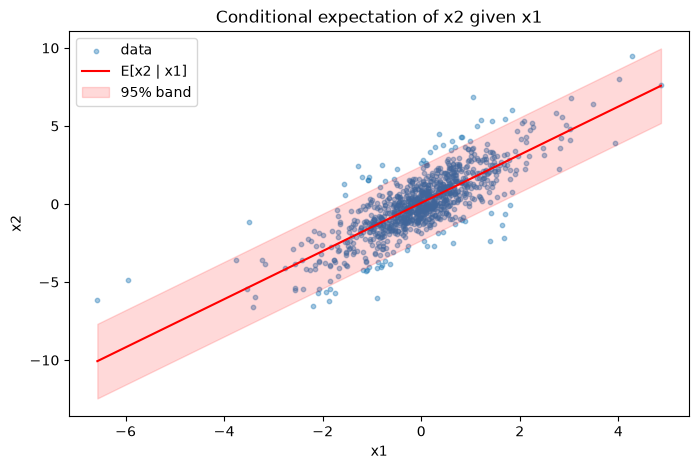

In [21]:
mu1 = problem4["x1"].mean()
mu2 = problem4["x2"].mean()
beta = sigma12 / sigma11  # coefficient on x1

x1_grid = np.linspace(problem4["x1"].min(), problem4["x1"].max(), 200)
cond_mean = mu2 + beta * (x1_grid - mu1)
cond_std = np.sqrt(cond_var_x2_given_x1)  # constant, doesn't depend on x1

band = 1.96 * cond_std

plt.figure(figsize=(8, 5))
plt.scatter(problem4["x1"], problem4["x2"], alpha=0.4, s=10, label="data")
plt.plot(x1_grid, cond_mean, color="red", label="E[x2 | x1]")
plt.fill_between(x1_grid, cond_mean - band, cond_mean + band, color="red", alpha=0.15, label="95% band")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Conditional expectation of x2 given x1")
plt.legend()
plt.show()


### 4.d

In [22]:
cond_mean_at_data = mu2 + beta * (problem4["x1"] - mu1)

lower = cond_mean_at_data - 1.96 * cond_std
upper = cond_mean_at_data + 1.96 * cond_std
inside = (problem4["x2"] >= lower) & (problem4["x2"] <= upper)

frac_inside = inside.mean()
print(f"Fraction inside the 95% band = {frac_inside:.4f} ({inside.sum()} of {len(problem4)})")


Fraction inside the 95% band = 0.9350 (935 of 1000)


### 4.e

In [23]:
std1 = np.sqrt(sigma11)
z1 = (problem4["x1"] - mu1).abs() / std1

buckets = {
    "|z1| < 1 (inside 1 std)": z1 < 1,
    "1 <= |z1| < 2 (1-2 std)": (z1 >= 1) & (z1 < 2),
    "|z1| >= 2 (beyond 2 std)": z1 >= 2,
}

for label, mask in buckets.items():
    n_bucket = mask.sum()
    cov_bucket = inside[mask].mean()
    print(f"{label:28s}  n={n_bucket:4d}  coverage={cov_bucket:.4f}")


|z1| < 1 (inside 1 std)       n= 759  coverage=0.9565
1 <= |z1| < 2 (1-2 std)       n= 190  coverage=0.8579
|z1| >= 2 (beyond 2 std)      n=  51  coverage=0.9020


In [24]:
resid = problem4["x2"] - cond_mean_at_data

for label, mask in buckets.items():
    r = resid[mask]
    print(f"{label:28s}  n={mask.sum():4d}  resid std={r.std():.4f}")


|z1| < 1 (inside 1 std)       n= 759  resid std=1.0758
1 <= |z1| < 2 (1-2 std)       n= 190  resid std=1.5804
|z1| >= 2 (beyond 2 std)      n=  51  resid std=1.5957


### 4.f

The residual standard deviation around the conditional-mean line grows sharply with |x1|, so the data shows that the conditional variance is not constant in x1. `x2` gets noisier around its expected value the further x1 is from its own mean.

The constant-width band relied on Var(x2 | x1) = Σ22 − Σ21Σ11⁻¹Σ12 being a single fixed number, independent of x1. Since we now observe conditional variance clearly increasing with |x1|, the data are not actually jointly Normal. So, the homoskedasticity-in-x1 assumption behind the flat band is the one that fails.

The part still hold from part c is the conditional-mean line itself, $E[x_2\mid x_1] = \mu_2 + \Sigma_{21}\Sigma_{11}^{-1}(x_1-\mu_1)$, and the identification of its slope as the OLS coefficient $\text{cov}(x_1,x_2)/\text{var}(x_1)$. That result only requires means, variances, and covariances to exist.

But treating that formula as the conditional expectation of x2 given x1 does not hold. That band requiers the multivariate normality specifically to make the conditional variance homoskedastic in x1.


## Question 5

In [25]:
# Q5
problem5 = pd.read_csv("problem5.csv")
problem5.head()


,x
0,1.077228
1,0.652277
2,0.798372
3,-0.309168
4,1.652842


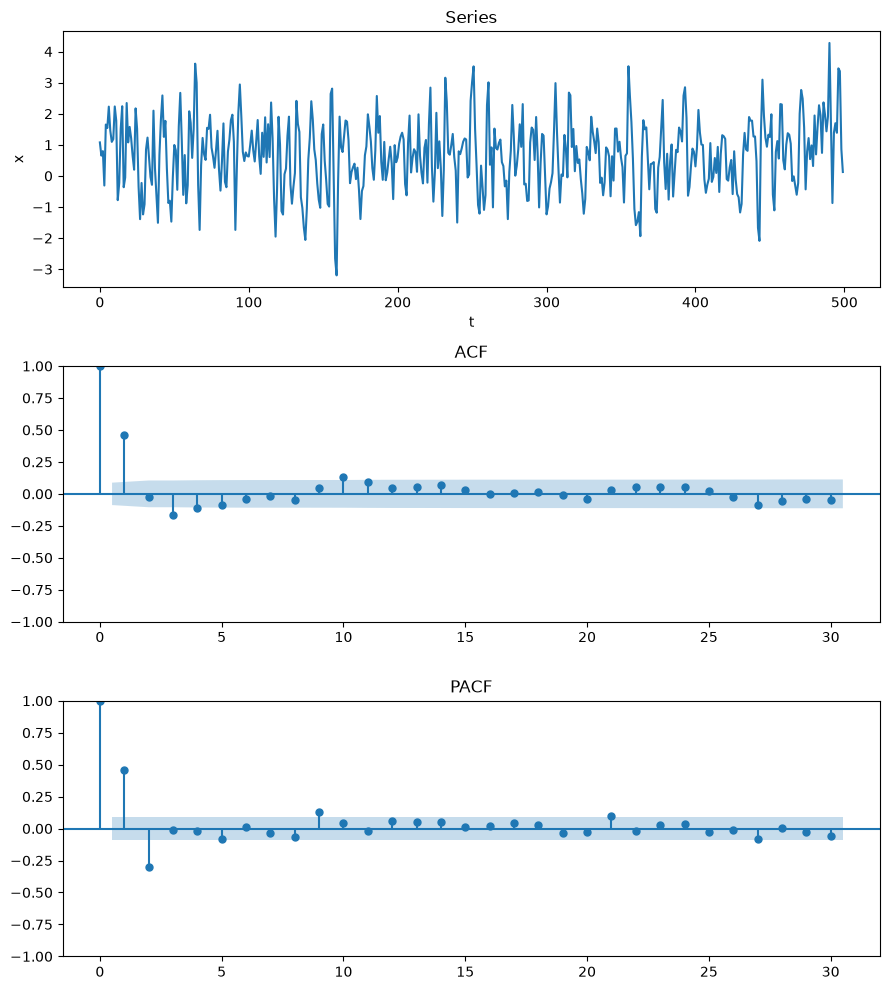

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 1, figsize=(9, 10))

axes[0].plot(problem5["x"])
axes[0].set_title("Series")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x")

plot_acf(problem5["x"], ax=axes[1], lags=30)
axes[1].set_title("ACF")

plot_pacf(problem5["x"], ax=axes[2], lags=30, method="ywm")
axes[2].set_title("PACF")

plt.tight_layout()
plt.show()


### 5.a

In PACF, lags 1 (≈0.46) and 2 (≈-0.30) are outside the band, then it's basically inside the band after that.

In ACF decays, it stays outside the band on and off across several lags (1, 3, 4, 10, 11) instead of stopping cleanly.

Cutoff in PACF and decay in ACF is likely to be an AR process. Since PACF cuts off after lag 2, the order is 2 → **AR(2)**.


### 5.b 

In PACF, lags 1 (≈0.46) and 2 (≈-0.30) are outside the band, then it's basically inside the band after that.

In ACF decays, it stays outside the band on and off across several lags (1, 3, 4, 10, 11) instead of stopping cleanly.

Cutoff in PACF and decay in ACF is likely to be an AR process. Since PACF cuts off after lag 2, the order is 2 → **AR(2)**.

### 5.c

In [27]:
from statsmodels.tsa.arima.model import ARIMA

orders = {
    "AR(1)": (1, 0, 0),
    "AR(2)": (2, 0, 0),
    "AR(3)": (3, 0, 0),
    "MA(1)": (0, 0, 1),
    "MA(2)": (0, 0, 2),
    "MA(3)": (0, 0, 3),
}

results = {}
for name, order in orders.items():
    fit = ARIMA(problem5["x"], order=order).fit()
    results[name] = fit
    print(f"{name:6s}  AICc = {fit.aicc:.3f}")
    print(fit.params.to_string())
    print()


AR(1)   AICc = 1418.587
const     0.670664
ar.L1     0.461053
sigma2    0.986801

AR(2)   AICc = 1372.438
const     0.670607
ar.L1     0.601201
ar.L2    -0.302638
sigma2    0.895802

AR(3)   AICc = 1374.343
const     0.670484
ar.L1     0.596203
ar.L2    -0.292690
ar.L3    -0.016542
sigma2    0.895558

MA(1)   AICc = 1389.084
const     0.671300
ma.L1     0.529601
sigma2    0.930102

MA(2)   AICc = 1381.232
const     0.670989
ma.L1     0.631356
ma.L2     0.161482
sigma2    0.911749

MA(3)   AICc = 1374.117
const     0.670895
ma.L1     0.593080
ma.L2     0.064825
ma.L3    -0.155454
sigma2    0.895105



### 5.d

AR(2) (1372.44) is the lowest of the six.

Yes, this matches the prediction from previous questions.


### 5.e


In [28]:
ar2, ar3 = results["AR(2)"], results["AR(3)"]


tss = ((problem5["x"] - problem5["x"].mean()) ** 2).sum()
r2_ar2 = 1 - (ar2.resid**2).sum() / tss
r2_ar3 = 1 - (ar3.resid**2).sum() / tss

print(f"\nlog-likelihood: AR(2)={ar2.llf:.4f}  AR(3)={ar3.llf:.4f}  diff={ar3.llf - ar2.llf:.4f}")
print(f"SSE:            AR(2)={(ar2.resid**2).sum():.4f}  AR(3)={(ar3.resid**2).sum():.4f}")
print(f"R^2:            AR(2)={r2_ar2:.6f}  AR(3)={r2_ar3:.6f}")
print(f"AICc:           AR(2)={ar2.aicc:.4f}  AR(3)={ar3.aicc:.4f}")



log-likelihood: AR(2)=-682.1788  AR(3)=-682.1109  diff=0.0679
SSE:            AR(2)=447.9567  AR(3)=447.8345
R^2:            AR(2)=0.285730  AR(3)=0.285925
AICc:           AR(2)=1372.4383  AR(3)=1374.3432


### 5.e

AIC focus more on quality then model complexity. Going from AR(2) to AR(3) costs one more estimated parameter, and AICc charges a fixed penalty for that. The AR(3) fit only ehave small improvement but relatively larger penalty. So AICc nets out higher for AR(3) (1374.34 vs. 1372.44) and rejects it.

$R^2$ has no complexity penalty, so adding any regressor will improve the model performance. So $R^2$ for AR(3) is guaranteed to be greater than or equal to AR(2)'s. AICc, on the other hand, is explicitly penalizing parameter count.
